In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import os

project_path = '/content/drive/MyDrive/cnn_project'
os.makedirs(project_path, exist_ok=True)

In [ ]:
import os
os.environ['KERAS_HOME'] = '/content/drive/MyDrive/keras_cache'

In [ ]:
# Create folder structure
os.makedirs(f'{project_path}/notebooks', exist_ok=True)
os.makedirs(f'{project_path}/checkpoints/cnn1', exist_ok=True)
os.makedirs(f'{project_path}/checkpoints/cnn2', exist_ok=True)
os.makedirs(f'{project_path}/models', exist_ok=True)

In [3]:
import tensorflow as tf

In [4]:
import tensorflow.keras
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Input, Flatten, Rescaling, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import RMSprop, Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

In [5]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 566s 3us/step


In [6]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [ ]:
X_train.shape

(50000, 32, 32, 3)

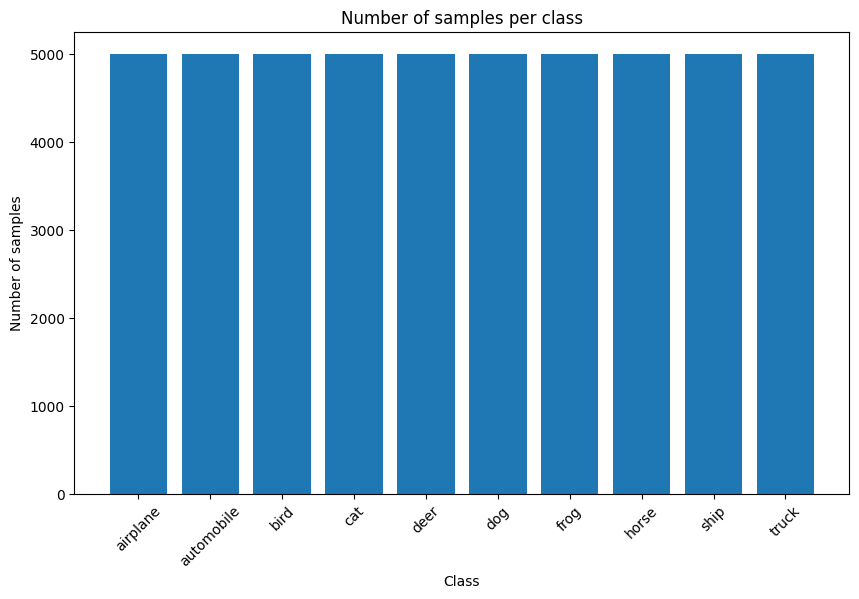

airplane: 5000
automobile: 5000
bird: 5000
cat: 5000
deer: 5000
dog: 5000
frog: 5000
horse: 5000
ship: 5000
truck: 5000


In [ ]:
# Check the training set balance
from collections import Counter


labels = y_train

# Count the number of samples per class
class_counts = Counter(labels.flatten())

# Sort by class index
classes = sorted(class_counts.keys())
counts = [class_counts[c] for c in classes]


# Plotting
plt.figure(figsize=(10, 6))
plt.bar(class_names, counts)
plt.xlabel('Class')
plt.ylabel('Number of samples')
plt.title('Number of samples per class')
plt.xticks(rotation=45)
plt.show()

# Optional: print counts for reference
for cls, count in zip(class_names, counts):
    print(f"{cls}: {count}")


The training dataset is balanced, with 5000 pictures for every class.

In [7]:
# Convert labels to one-hot vectors
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

In [8]:
# Rescalling data
normalization_layer = Rescaling(1./255)
X_train_norm = normalization_layer(X_train)
X_test_norm = normalization_layer(X_test)

print(X_train_norm.shape[0], 'train samples')
print(X_test_norm.shape[0], 'test samples')

50000 train samples
10000 test samples


In [ ]:
print(X_train_norm)

tf.Tensor(
[[[[0.23137257 0.24313727 0.24705884]
   [0.16862746 0.18039216 0.1764706 ]
   [0.19607845 0.18823531 0.16862746]
   ...
   [0.61960787 0.5176471  0.42352945]
   [0.59607846 0.4901961  0.40000004]
   [0.5803922  0.48627454 0.4039216 ]]

  [[0.0627451  0.07843138 0.07843138]
   [0.         0.         0.        ]
   [0.07058824 0.03137255 0.        ]
   ...
   [0.48235297 0.34509805 0.21568629]
   [0.4666667  0.3254902  0.19607845]
   [0.4784314  0.34117648 0.22352943]]

  [[0.09803922 0.09411766 0.08235294]
   [0.0627451  0.02745098 0.        ]
   [0.19215688 0.10588236 0.03137255]
   ...
   [0.46274513 0.32941177 0.19607845]
   [0.47058827 0.32941177 0.19607845]
   [0.427451   0.28627452 0.16470589]]

  ...

  [[0.81568635 0.6666667  0.37647063]
   [0.78823537 0.6        0.13333334]
   [0.77647066 0.6313726  0.10196079]
   ...
   [0.627451   0.52156866 0.27450982]
   [0.21960786 0.12156864 0.02745098]
   [0.20784315 0.13333334 0.07843138]]

  [[0.7058824  0.54509807 0.376470

In [ ]:
##### Build the model

model = Sequential([Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),
                    MaxPooling2D(2,2),
                    Conv2D(64, (3,3), activation='relu'),
                    MaxPooling2D(2,2),
                    Flatten(),
                    Dense(128, activation='relu'),
                    Dense(10, activation='softmax')
                    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
project_path = '/content/drive/MyDrive/cnn_project'

checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn1/best_model.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_accuracy',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

history = model.fit(X_train_norm, y_train_cat,
          validation_split=0.2, # Keras takes the last 20% of X_train automatically
          epochs=50, # set high — early stopping will interrupt,
          batch_size=32,
          callbacks=[checkpoint, early_stopping])

Epoch 1/50
1243/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3738 - loss: 1.7171
Epoch 1: val_accuracy improved from None to 0.57090, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.4649 - loss: 1.4842 - val_accuracy: 0.5709 - val_loss: 1.2137
Epoch 2/50
1240/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5953 - loss: 1.1400
Epoch 2: val_accuracy improved from 0.57090 to 0.61900, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6096 - loss: 1.1060 - val_accuracy: 0.6190 - val_loss: 1.0846
Epoch 3/50
1236/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6633 - loss: 0.9650
Epoch 3: v

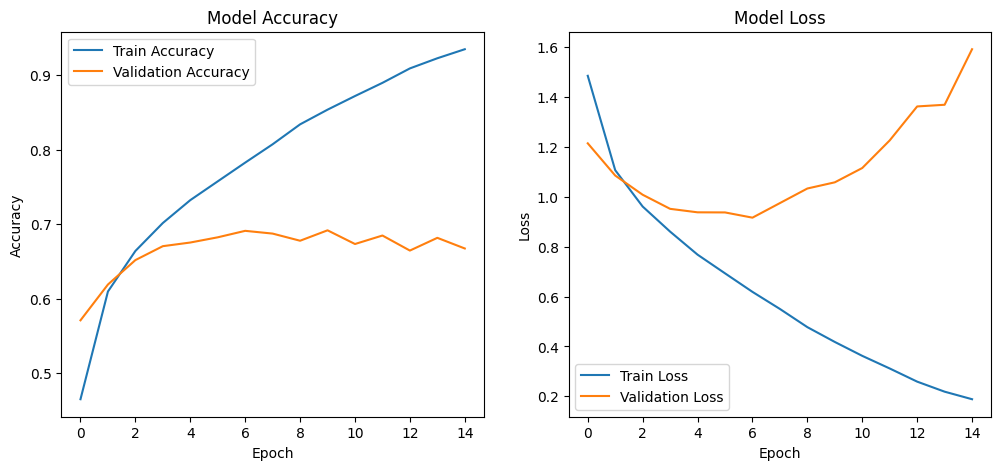

In [ ]:
import matplotlib.pylab as plt
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [ ]:
model.save(f'{project_path}/models/cnn1_final.keras')

In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model(f'{project_path}/models/cnn1_final.keras')

In [ ]:
score = best_model.evaluate(X_test_norm, y_test_cat, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 1.081868290901184
Test accuracy: 0.6883000135421753


The model's accuracy was low and the loss was high, meaning the model needs improvement.

For model_2, additional convolutional layers before the pooling layer and a dropout layer will be added.

In [ ]:
# Addition of 2 convolutional layers (1 before each pooling layer) and 1 dropout layer (after the last pooling)
model_2 = Sequential([Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),
                    Conv2D(64,(3,3), activation='relu'),
                    MaxPooling2D(2,2),
                    Conv2D(128, (3,3), activation='relu'),
                    Conv2D(256, (3,3), activation='relu'),
                    MaxPooling2D(2,2),
                    Dropout(0.2),
                    Flatten(),
                    Dense(512, activation='relu'),
                    Dense(10, activation='softmax')
                    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_2.summary()
model_2.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,670,858 (14.00 MB)

 Trainable params: 3,670,858 (14.00 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

project_path = '/content/drive/MyDrive/cnn_project'

checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn1/best_model_2.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_accuracy',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

history = model_2.fit(X_train_norm, y_train_cat,
          validation_split=0.2, # Keras takes the last 20% of X_train automatically
          epochs=50, # set high — early stopping will interrupt,
          batch_size=32,
          callbacks=[checkpoint, early_stopping])

Epoch 1/50
1247/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3827 - loss: 1.6535
Epoch 1: val_accuracy improved from None to 0.62940, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_2.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.4886 - loss: 1.3972 - val_accuracy: 0.6294 - val_loss: 1.0579
Epoch 2/50
1242/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6484 - loss: 0.9917
Epoch 2: val_accuracy improved from 0.62940 to 0.71210, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_2.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6651 - loss: 0.9454 - val_accuracy: 0.7121 - val_loss: 0.8181
Epoch 3/50
1248/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7329 - loss: 0.7530
Ep

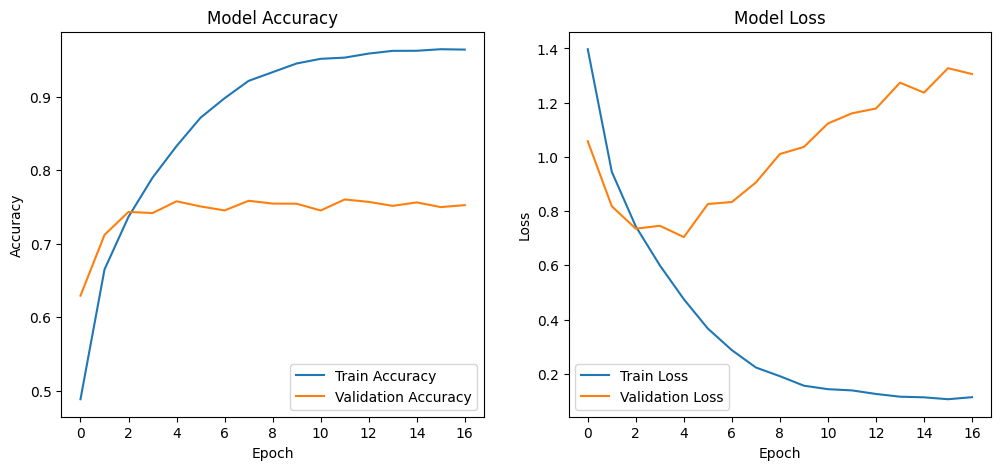

In [ ]:
import matplotlib.pylab as plt
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


Model_2 showed an increase in both training as validation accuracy and training loss. Validation loss is still high and the model is overfitting.

For model_3, Flatten and Dense layers with be replaced with a pooling layer (GlobalAveragePooling).

In [ ]:
# Replace Flatten and Dense layers with GlobalAveragePooling
model_3 = Sequential([Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),
                    Conv2D(64,(3,3), activation='relu'),
                    MaxPooling2D(2,2),
                    Conv2D(128, (3,3), activation='relu'),
                    Conv2D(256, (3,3), activation='relu'),
                    MaxPooling2D(2,2),
                    Dropout(0.2),
                    GlobalAveragePooling2D(),
                    Dense(10, activation='softmax')
                    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_3.summary()
model_3.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 390,986 (1.49 MB)

 Trainable params: 390,986 (1.49 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

project_path = '/content/drive/MyDrive/cnn_project'

checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn1/best_model_3.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_accuracy',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

history = model_3.fit(X_train_norm, y_train_cat,
          validation_split=0.2, # Keras takes the last 20% of X_train automatically
          epochs=50, # set high — early stopping will interrupt,
          batch_size=32,
          callbacks=[checkpoint, early_stopping])

Epoch 1/50
1249/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2948 - loss: 1.8324
Epoch 1: val_accuracy improved from None to 0.51220, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_3.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_3.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.3831 - loss: 1.6340 - val_accuracy: 0.5122 - val_loss: 1.3651
Epoch 2/50
1246/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5293 - loss: 1.3164
Epoch 2: val_accuracy improved from 0.51220 to 0.59830, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_3.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_3.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5548 - loss: 1.2473 - val_accuracy: 0.5983 - val_loss: 1.1357
Epoch 3/50
1247/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6142 - loss: 1.0921
Ep

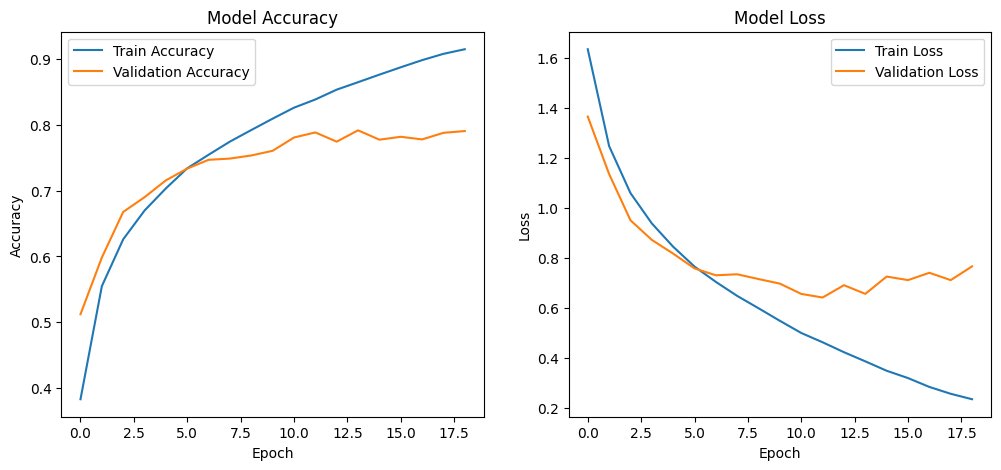

In [ ]:
import matplotlib.pylab as plt
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

The overfitting was reduced with the reduction of training accuracy and increasing of vald+idation accuracy. Validation loss is still high.

For model_4, dropout will be increased to 0.5.

In [ ]:
# Increase dropout to 0.5
model_4 = Sequential([Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),
                    Conv2D(64,(3,3), activation='relu'),
                    MaxPooling2D(2,2),
                    Conv2D(128, (3,3), activation='relu'),
                    Conv2D(256, (3,3), activation='relu'),
                    MaxPooling2D(2,2),
                    Dropout(0.5),
                    GlobalAveragePooling2D(),
                    Dense(10, activation='softmax')
                    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_4.summary()
model_4.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 390,986 (1.49 MB)

 Trainable params: 390,986 (1.49 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

project_path = '/content/drive/MyDrive/cnn_project'

checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn1/best_model_4.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_accuracy',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

history_4 = model_4.fit(X_train_norm, y_train_cat,
          validation_split=0.2, # Keras takes the last 20% of X_train automatically
          epochs=50, # set high — early stopping will interrupt,
          batch_size=32,
          callbacks=[checkpoint, early_stopping])

Epoch 1/50
1246/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2812 - loss: 1.8848
Epoch 1: val_accuracy improved from None to 0.49330, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_4.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_4.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.3717 - loss: 1.6718 - val_accuracy: 0.4933 - val_loss: 1.4069
Epoch 2/50
1245/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5096 - loss: 1.3558
Epoch 2: val_accuracy improved from 0.49330 to 0.57280, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_4.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_4.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5318 - loss: 1.3023 - val_accuracy: 0.5728 - val_loss: 1.1785
Epoch 3/50
1247/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5886 - loss: 1.1621
Ep

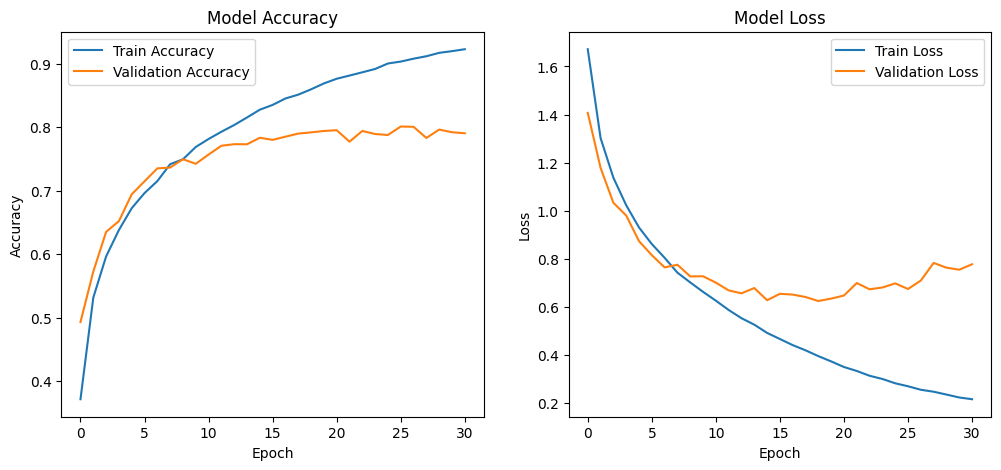

In [ ]:
import matplotlib.pylab as plt
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_4.history['accuracy'], label='Train Accuracy')
plt.plot(history_4.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_4.history['loss'], label='Train Loss')
plt.plot(history_4.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

The accuracy of both training and validation improved, training loss decreased but the validation loss is still high.

For model_5, BatchNormalization after convolutional layers will be added.

In [ ]:
# Add batch normalization
model_5 = Sequential([Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),
                    Conv2D(64,(3,3), activation='relu'),
                      BatchNormalization(),
                    MaxPooling2D(2,2),
                    Conv2D(128, (3,3), activation='relu'),
                    Conv2D(256, (3,3), activation='relu'),
                      BatchNormalization(),
                    MaxPooling2D(2,2),
                    Dropout(0.5),
                    GlobalAveragePooling2D(),
                    Dense(10, activation='softmax')
                    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_5.summary()
model_5.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 392,266 (1.50 MB)

 Trainable params: 391,626 (1.49 MB)

 Non-trainable params: 640 (2.50 KB)

In [ ]:
#change monitor to 'val_loss'
checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn1/best_model_5.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_loss',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

history_5 = model_5.fit(X_train_norm, y_train_cat,
          validation_split=0.2, # Keras takes the last 20% of X_train automatically
          epochs=50, # set high — early stopping will interrupt,
          batch_size=32,
          callbacks=[checkpoint, early_stopping])

Epoch 1/50
1247/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4214 - loss: 1.6067
Epoch 1: val_loss improved from None to 1.50902, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_5.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_5.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.5027 - loss: 1.3850 - val_accuracy: 0.5066 - val_loss: 1.5090
Epoch 2/50
1242/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6402 - loss: 1.0212
Epoch 2: val_loss improved from 1.50902 to 0.97879, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_5.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_5.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6571 - loss: 0.9816 - val_accuracy: 0.6552 - val_loss: 0.9788
Epoch 3/50
1243/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7082 - loss: 0.8423
Epoch 3: v

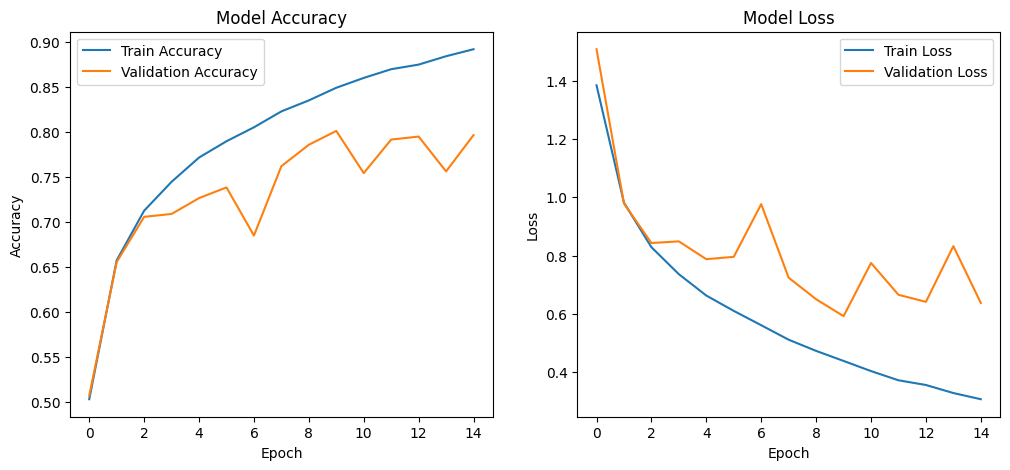

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_5.history['accuracy'], label='Train Accuracy')
plt.plot(history_5.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_5.history['loss'], label='Train Loss')
plt.plot(history_5.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

The overfitting was reduced, but the training and validation loss are still high.

For model 6, the leraning rate of the Adam optimizer will be reduced.

In [ ]:
# Decrease the learning rate of Adam optimizer to 1e-5
model_6 = Sequential([Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),
                    Conv2D(64,(3,3), activation='relu'),
                      BatchNormalization(),
                    MaxPooling2D(2,2),
                    Conv2D(128, (3,3), activation='relu'),
                    Conv2D(256, (3,3), activation='relu'),
                      BatchNormalization(),
                    MaxPooling2D(2,2),
                    Dropout(0.5),
                    GlobalAveragePooling2D(),
                    Dense(10, activation='softmax')
                    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Reduce learning rate
model_6.summary()
model_6.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 392,266 (1.50 MB)

 Trainable params: 391,626 (1.49 MB)

 Non-trainable params: 640 (2.50 KB)

In [ ]:
checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn1/best_model_6.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_loss',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

history_6 = model_6.fit(X_train_norm, y_train_cat,
          validation_split=0.2, # Keras takes the last 20% of X_train automatically
          epochs=50, # set high — early stopping will interrupt,
          batch_size=32,
          callbacks=[checkpoint, early_stopping])

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2714 - loss: 2.0223
Epoch 1: val_loss improved from None to 1.58906, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_6.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_6.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.3329 - loss: 1.8347 - val_accuracy: 0.4290 - val_loss: 1.5891
Epoch 2/50
1244/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4233 - loss: 1.6038
Epoch 2: val_loss improved from 1.58906 to 1.45713, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_6.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_6.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4350 - loss: 1.5698 - val_accuracy: 0.4799 - val_loss: 1.4571
Epoch 3/50
1244/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4682 - loss: 1.4836
Epoch 3: 

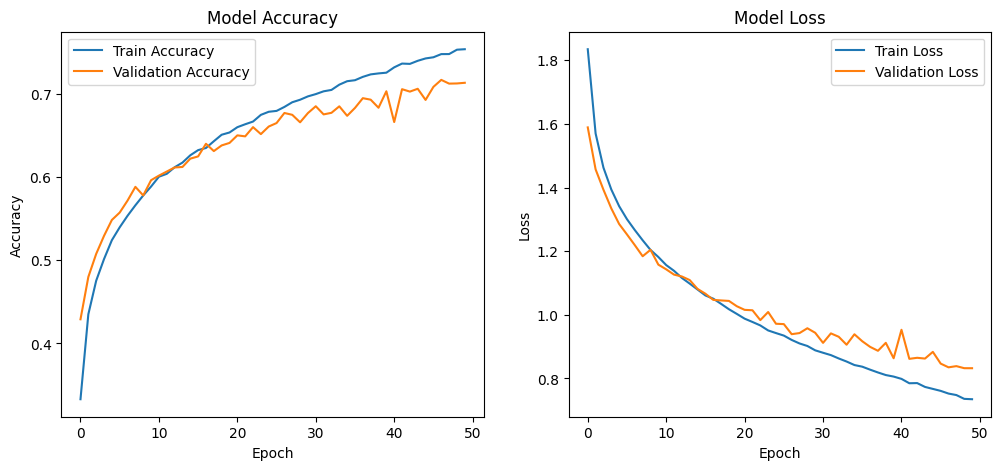

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_6.history['accuracy'], label='Train Accuracy')
plt.plot(history_6.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_6.history['loss'], label='Train Loss')
plt.plot(history_6.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

The reduction of the learning rate employed on model 6 did not improve the model's performance.
For the next test, l2 regularization will be performed on model 5.

In [ ]:
# Add L2 regularization
model_7 = Sequential([Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3),kernel_regularizer=l2(1e-4)),
                    Conv2D(64,(3,3), activation='relu', kernel_regularizer=l2(1e-4)),
                      BatchNormalization(),
                    MaxPooling2D(2,2),
                    Conv2D(128, (3,3), activation='relu', kernel_regularizer=l2(1e-4)),
                    Conv2D(256, (3,3), activation='relu', kernel_regularizer=l2(1e-4)),
                    MaxPooling2D(2,2),
                    Dropout(0.5),
                    GlobalAveragePooling2D(),
                    Dense(10, activation='softmax')
                    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_7.summary()
model_7.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391,242 (1.49 MB)

 Trainable params: 391,114 (1.49 MB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn1/best_model_7.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_loss',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

history_7 = model_7.fit(X_train_norm, y_train_cat,
          validation_split=0.2, # Keras takes the last 20% of X_train automatically
          epochs=50, # set high — early stopping will interrupt,
          batch_size=32,
          callbacks=[checkpoint, early_stopping])

Epoch 1/50
1243/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3913 - loss: 1.6762
Epoch 1: val_loss improved from None to 1.45425, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_7.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_7.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.4846 - loss: 1.4548 - val_accuracy: 0.5125 - val_loss: 1.4543
Epoch 2/50
1242/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6293 - loss: 1.1210
Epoch 2: val_loss improved from 1.45425 to 1.06847, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_7.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_7.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6453 - loss: 1.0711 - val_accuracy: 0.6426 - val_loss: 1.0685
Epoch 3/50
1248/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6932 - loss: 0.9539
Epoch 3: v

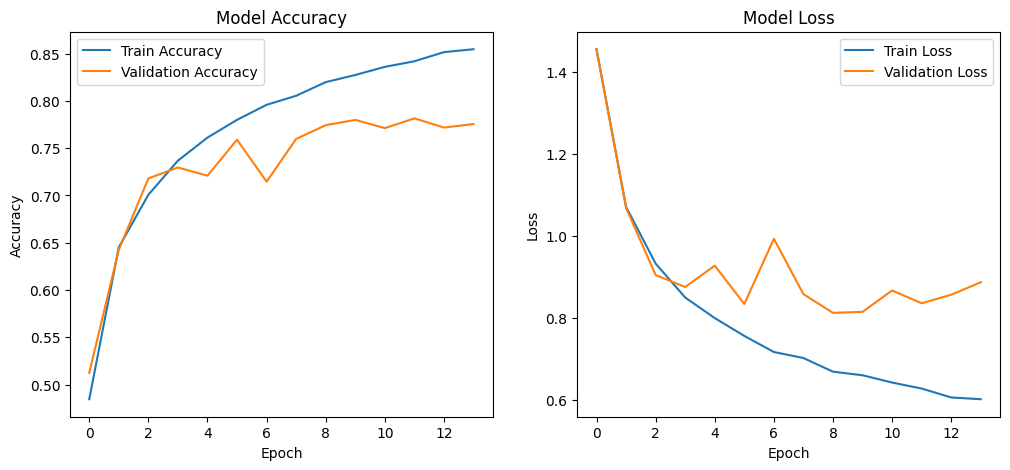

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_7.history['accuracy'], label='Train Accuracy')
plt.plot(history_7.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_7.history['loss'], label='Train Loss')
plt.plot(history_7.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

When compared with model 5, the L2 regularization did not improve the model's performance.

In [ ]:
# Add batch normalization
model_5 = Sequential([Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),
                    Conv2D(64,(3,3), activation='relu'),
                      BatchNormalization(),
                    MaxPooling2D(2,2),
                    Conv2D(128, (3,3), activation='relu'),
                    Conv2D(256, (3,3), activation='relu'),
                      BatchNormalization(),
                    MaxPooling2D(2,2),
                    Dropout(0.5),
                    GlobalAveragePooling2D(),
                    Dense(10, activation='softmax')
                    ])

Model 8 Has padding and Normalisation after each Conv step / Dense changed from Model 5 / we have two dropouts .2 and  .3 instead of .5

For model_8, padding and BatchNormalization will be added to each convolutional step. A dropout layer will be added after the first pooling layer and the original dropout layer was adjusted.

In [ ]:
# Add BatchNormalization after each Conv2D. Add Dropout after the first MaxPooling2D. Adjust last Dropout.
model_8 = Sequential([

    Conv2D(
        32,
        (3,3),
        padding='same',
        activation='relu',
        input_shape=(32,32,3)
    ),
    BatchNormalization(),

    Conv2D(
        64,
        (3,3),
        padding='same',
        activation='relu'
    ),
    BatchNormalization(),

    MaxPooling2D(2,2),
    Dropout(0.2),

    Conv2D(
        128,
        (3,3),
        padding='same',
        activation='relu'
    ),
    BatchNormalization(),

    Conv2D(
        256,
        (3,3),
        padding='same',
        activation='relu'
    ),
    BatchNormalization(),

    MaxPooling2D(2,2),
    Dropout(0.3),

    GlobalAveragePooling2D(),

    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_8.summary()
model_8.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 392,906 (1.50 MB)

 Trainable params: 391,946 (1.50 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn1/best_model_8.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_loss',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

history_8 = model_8.fit(X_train_norm, y_train_cat,
          validation_split=0.2, # Keras takes the last 20% of X_train automatically
          epochs=50, # set high — early stopping will interrupt,
          batch_size=32,
          callbacks=[checkpoint, early_stopping])

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9201 - loss: 0.2281
Epoch 1: val_loss improved from None to 0.62437, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_8.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_8.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.9147 - loss: 0.2436 - val_accuracy: 0.8209 - val_loss: 0.6244
Epoch 2/50
1248/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9262 - loss: 0.2136
Epoch 2: val_loss improved from 0.62437 to 0.58604, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_8.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_8.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.9197 - loss: 0.2294 - val_accuracy: 0.8246 - val_loss: 0.5860
Epoch 3/50
1246/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9297 - loss: 0.1994
Epoch 3:

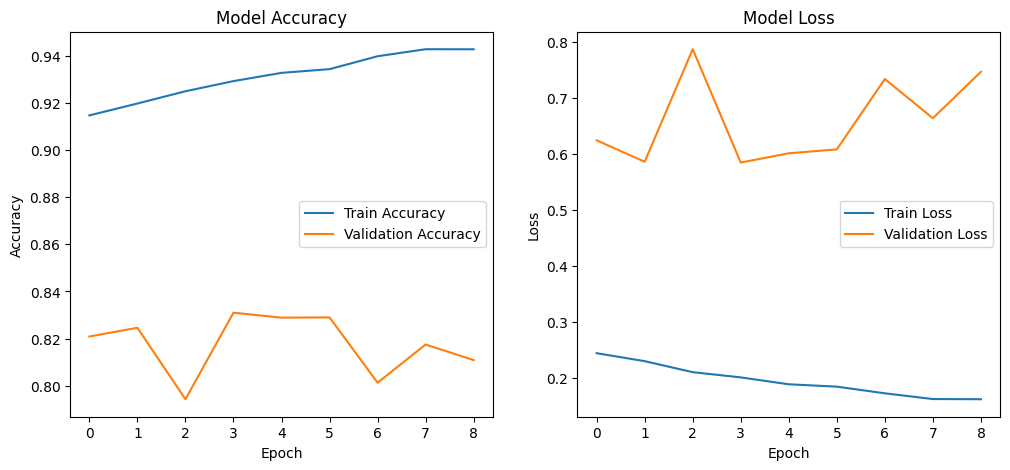

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_8.history['accuracy'], label='Train Accuracy')
plt.plot(history_8.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_8.history['loss'], label='Train Loss')
plt.plot(history_8.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Both accuracies and losses improved over model_5.

For model_9, reduction of learning rate on plateau checkpoint will be added.

In [ ]:
#ReduceLROnPlateu
model_9 = Sequential([

    Conv2D(
        32,
        (3,3),
        padding='same',
        activation='relu',
        input_shape=(32,32,3)
    ),
    BatchNormalization(),

    Conv2D(
        64,
        (3,3),
        padding='same',
        activation='relu'
    ),
    BatchNormalization(),

    MaxPooling2D(2,2),
    Dropout(0.2),

    Conv2D(
        128,
        (3,3),
        padding='same',
        activation='relu'
    ),
    BatchNormalization(),

    Conv2D(
        256,
        (3,3),
        padding='same',
        activation='relu'
    ),
    BatchNormalization(),

    MaxPooling2D(2,2),
    Dropout(0.3),

    GlobalAveragePooling2D(),

    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_9.summary()
model_9.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 392,906 (1.50 MB)

 Trainable params: 391,946 (1.50 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn1/best_model_9.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_loss',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

reduce_LR = ReduceLROnPlateau(
           monitor='val_loss',
            factor=0.5,
            patience=2
)

history_9 = model_9.fit(X_train_norm, y_train_cat,
          validation_data=(X_test_norm, y_test_cat),
          epochs=50, # set high — early stopping will interrupt,
          batch_size=32,
          callbacks=[checkpoint, early_stopping,reduce_LR])

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4784 - loss: 1.4739
Epoch 1: val_loss improved from None to 1.10695, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_9.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_9.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 13ms/step - accuracy: 0.5590 - loss: 1.2396 - val_accuracy: 0.6040 - val_loss: 1.1070 - learning_rate: 0.0010
Epoch 2/50
1560/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6841 - loss: 0.9062
Epoch 2: val_loss improved from 1.10695 to 1.09117, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_9.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_9.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6963 - loss: 0.8706 - val_accuracy: 0.6341 - val_loss: 1.0912 - learning_rate: 0.0010
Epoch 3/50
1560/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 8

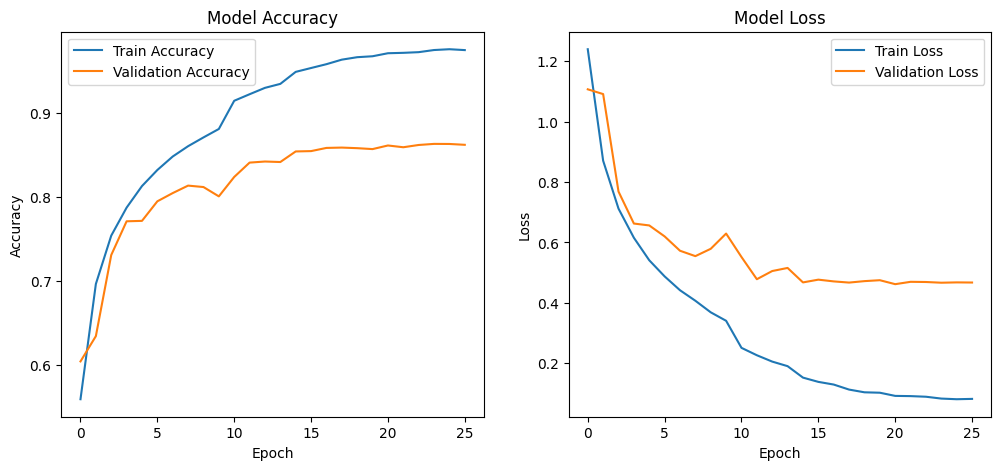

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_9.history['accuracy'], label='Train Accuracy')
plt.plot(history_9.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_9.history['loss'], label='Train Loss')
plt.plot(history_9.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Both accuracies and losses improved.

An additional dropout layer will be added before the output layer.

In [ ]:
# Add Dropout before output layer.
model_10 = Sequential([

    Conv2D(
        32,
        (3,3),
        padding='same',
        activation='relu',
        input_shape=(32,32,3)
    ),
    BatchNormalization(),

    Conv2D(
        64,
        (3,3),
        padding='same',
        activation='relu'
    ),
    BatchNormalization(),

    MaxPooling2D(2,2),
    Dropout(0.2),

    Conv2D(
        128,
        (3,3),
        padding='same',
        activation='relu'
    ),
    BatchNormalization(),

    Conv2D(
        256,
        (3,3),
        padding='same',
        activation='relu'
    ),
    BatchNormalization(),

    MaxPooling2D(2,2),
    Dropout(0.3),

    GlobalAveragePooling2D(),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_10.summary()
model_10.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 392,906 (1.50 MB)

 Trainable params: 391,946 (1.50 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn1/best_model_10.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_loss',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

reduce_LR = ReduceLROnPlateau(
           monitor='val_loss',
            factor=0.5,
            patience=2
)


history_10 = model_10.fit(X_train_norm, y_train_cat,
          validation_split=0.2, # Keras takes the last 20% of X_train automatically
          epochs=50, # set high — early stopping will interrupt,
          batch_size=32,
          callbacks=[checkpoint, early_stopping, reduce_LR])

Epoch 1/50
1248/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3726 - loss: 1.7970
Epoch 1: val_loss improved from None to 1.26806, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_10.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_10.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - accuracy: 0.4700 - loss: 1.4870 - val_accuracy: 0.5533 - val_loss: 1.2681 - learning_rate: 0.0010
Epoch 2/50
1249/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6105 - loss: 1.0959
Epoch 2: val_loss improved from 1.26806 to 0.99748, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_10.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_10.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.6233 - loss: 1.0618 - val_accuracy: 0.6493 - val_loss: 0.9975 - learning_rate: 0.0010
Epoch 3/50
1246/1250 ━━━━━━━━━━━━━━━━━━━━ 0s

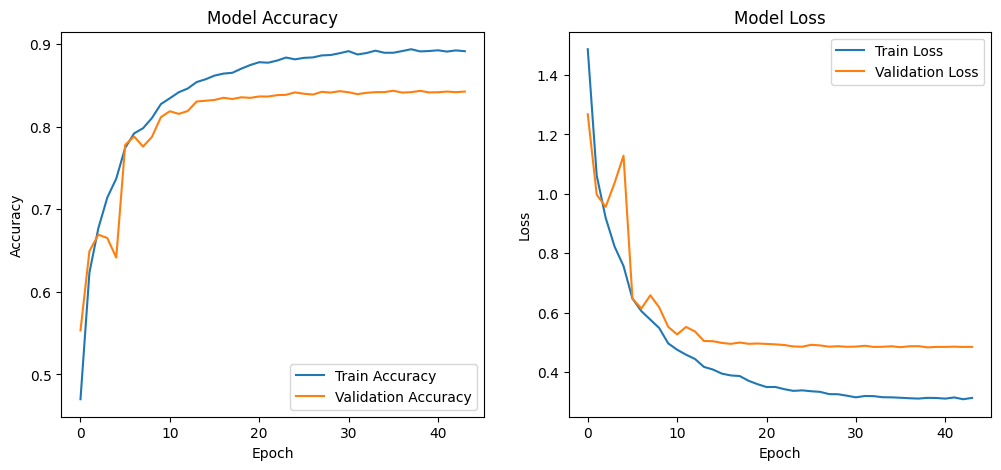

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_10.history['accuracy'], label='Train Accuracy')
plt.plot(history_10.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_10.history['loss'], label='Train Loss')
plt.plot(history_10.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
# Fitting results (best epoch was 39, which is index 38)
train_acc = history_10.history['accuracy'][38]
train_loss = history_10.history['loss'][38]
val_acc = history_10.history['val_accuracy'][38]
val_loss = history_10.history['val_loss'][38]

print("Epoch 39")
print(f"Train accuracy:{train_acc:.4f}")
print(f"Train loss:{train_loss:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")
print(f"Validation loss: {val_loss:.4f}")

Epoch 39
Train accuracy:0.8910
Train loss:0.3131
Validation accuracy: 0.8433
Validation loss: 0.4831


This model shows the best performance in term of accuracy and loss, without overfitting.

In [ ]:
# Evaluate method
test_loss, test_acc = model_10.evaluate(X_test_norm, y_test_cat)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8346 - loss: 0.4950
Test Accuracy: 0.8346
Test Loss: 0.4950


In [ ]:
# Predictions
y_pred_probs = model_10.predict(X_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [ ]:
# Classification report
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

    airplane       0.84      0.84      0.84      1000
  automobile       0.92      0.91      0.92      1000
        bird       0.75      0.75      0.75      1000
         cat       0.74      0.68      0.71      1000
        deer       0.78      0.83      0.81      1000
         dog       0.78      0.77      0.77      1000
        frog       0.83      0.90      0.87      1000
       horse       0.88      0.84      0.86      1000
        ship       0.91      0.92      0.91      1000
       truck       0.90      0.91      0.90      1000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



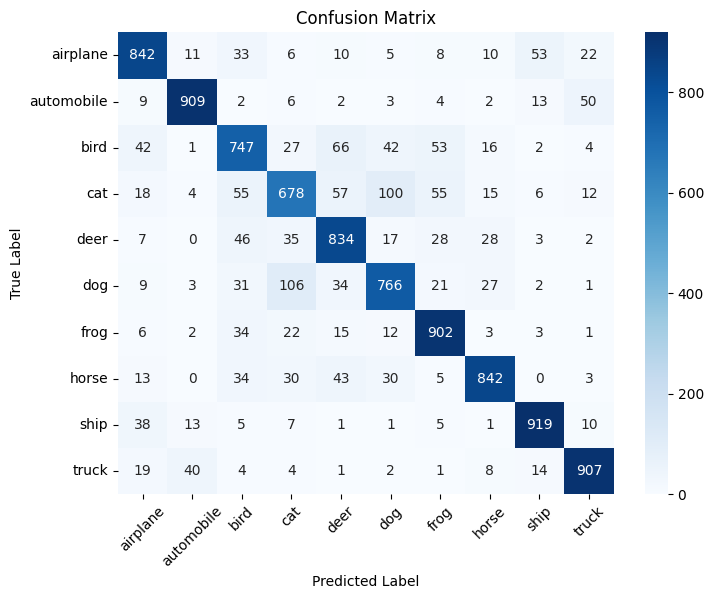

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

In [ ]:
# Save best model
model_10.save(f'{project_path}/models/cnn2_final.keras')

The model showed accuracy and macro avg precision, recall and f1-score of 0.83, showing it's performance should be improved.
The main confusion happens between cats and dogs.
It also has some difficulties identifying birds.

In [ ]:

# Setup data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2,
)

datagen.fit(X_train_norm)



In [ ]:
#Augmented
checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn1/best_model_10_aug.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_loss',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

reduce_LR = ReduceLROnPlateau(
           monitor='val_loss',
            factor=0.5,
            patience=2
)


history_10_aug = model_10.fit(
    datagen.flow(X_train_norm, y_train_cat, batch_size=64),
    epochs=50,
    callbacks=[checkpoint, early_stopping, reduce_LR]
)



Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7781 - loss: 0.6880
Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_10_aug.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.7818 - loss: 0.6812 - learning_rate: 1.9531e-06
Epoch 2/50
  1/782 ━━━━━━━━━━━━━━━━━━━━ 1:05 84ms/step - accuracy: 0.7969 - loss: 0.8575

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7835 - loss: 0.6787
Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_10_aug.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.7873 - loss: 0.6700 - learning_rate: 1.9531e-06
Epoch 3/50
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7843 - loss: 0.6768
Epoch 3: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_10_aug.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 47ms/step - accuracy: 0.7865 - loss: 0.6759 - learning_rate: 1.9531e-06
Epoch 4/50
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7866 - loss: 0.6680
Epoch 4: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_10_aug.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.7870 - loss: 0.6681 - learning_rate: 1.9531e-06
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7854 - loss: 0.6766
Epoch 5: finished 

#plotting all results

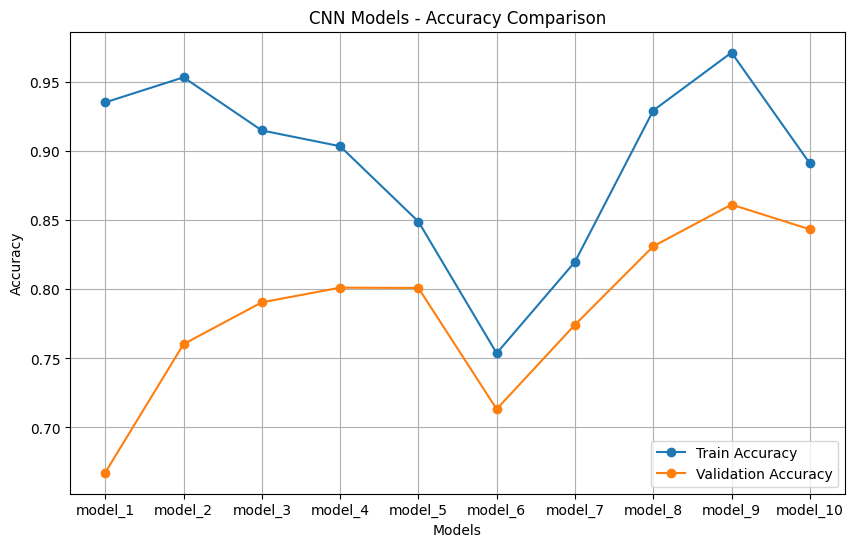

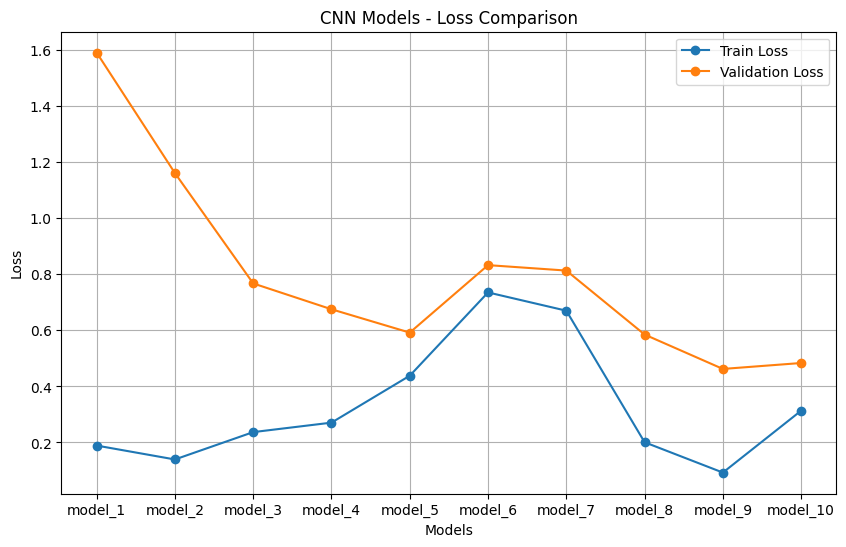

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create dataframe
results = pd.DataFrame({
    "Model": [
        "model_1",
        "model_2",
        "model_3",
        "model_4",
        "model_5",
        "model_6",
        "model_7",
        "model_8",
        "model_9",
        "model_10"
    ],

    "Train_Accuracy": [
        0.9351,
        0.9532,
        0.9148,
        0.9034,
        0.8489,
        0.7537,
        0.8198,
        0.9292,
        0.9711,
        0.8910
    ],

    "Validation_Accuracy": [
        0.6674,
        0.7603,
        0.7905,
        0.8011,
        0.8009,
        0.7133,
        0.7743,
        0.8310,
        0.8612,
        0.8433
    ],

    "Train_Loss": [
        0.1885,
        0.1389,
        0.2365,
        0.2703,
        0.4377,
        0.7349,
        0.6697,
        0.2003,
        0.0921,
        0.3131
    ],

    "Validation_Loss": [
        1.5907,
        1.1608,
        0.7670,
        0.6748,
        0.5915,
        0.8323,
        0.8129,
        0.5846,
        0.4619,
        0.4831
    ]
})

# -----------------------------
# Plot 1: Accuracy Comparison
# -----------------------------

plt.figure(figsize=(10,6))

plt.plot(
    results["Model"],
    results["Train_Accuracy"],
    marker='o',
    label='Train Accuracy'
)

plt.plot(
    results["Model"],
    results["Validation_Accuracy"],
    marker='o',
    label='Validation Accuracy'
)

plt.title("CNN Models - Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

# -----------------------------
# Plot 2: Loss Comparison
# -----------------------------

plt.figure(figsize=(10,6))

plt.plot(
    results["Model"],
    results["Train_Loss"],
    marker='o',
    label='Train Loss'
)

plt.plot(
    results["Model"],
    results["Validation_Loss"],
    marker='o',
    label='Validation Loss'
)

plt.title("CNN Models - Loss Comparison")
plt.xlabel("Models")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()